 # RAPIDO RIDE

#  Industry

Industry: Ride-Hailing / Mobility / Transportation Technology

# Business Background

Ride-hailing platforms receive thousands of ride requests every day. The successful completion of a ride depends on several factors:

Customer demand 

Driver availability

Pickup and drop locations

Distance and duration

Weather conditions

Surge pricing

Vehicle type

Time of booking

Customer experience

The uploaded dataset contains 5,083 ride records and 19 variables, including ride status, city, vehicle type, demand level, nearby drivers, weather, fares, payment method, and customer ratings.

# Business Problem

Driver cancellations

Customer cancellations

Surge pricing

Missing customer ratings

Weather-related operational challenges

# Business Goals
Reduce ride cancellations.

Improve ride completion rate.

Increase customer satisfaction.

Optimize driver allocation.

Improve revenue through better pricing and operations.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as py
import seaborn as sns

In [2]:
df = pd.read_csv("rapido_rides_messy.csv")

In [3]:
df.head()

,ride_id,customer_id,driver_id,city,pickup_area,drop_area,pickup_time,vehicle_type,distance_km,duration_min,demand_level,nearby_drivers,weather,surge_multiplier,base_fare,final_fare,payment_method,ride_status,customer_rating
0,RPD101737,CUST1538,DRV109,Bangalore,Jayanagar,Jayanagar,2026-06-28 03:47:00,NaN,2.17,21.2,Medium,26.0,NaN,1.09,41.04,44.73,UPI,Cancelled by Driver,NaN
1,RPD100673,CUST2062,DRV720,BANGALORE,Koramangala,Jayanagar,2026-06-14 13:33:00,Cab Economy,5.51,12.3,Very High,27.0,Heavy Rain,1.95,81.12,158.18,upi,completed,4.8
2,RPD100450,CUST3670,DRV552,hyderabad,Banjara Hills,Banjara Hills,2026-06-23 00:52:00,Cab Premium,3.62,17.4,Low,19.0,Cloudy,1.08,80.16,86.57,Wallet,Ongoing,NaN
3,RPD102088,CUST1816,DRV224,Bengaluru,MG Road,Indiranagar,2026-06-20 09:08:00,Bike,2.78,8.7,Very High,5.0,Clear,1.96,31.68,62.09,cash,COMPLETED,4.4
4,RPD101775,CUST1226,DRV185,BANGALORE,Electronic City,Jayanagar,2026-07-12 01:21:00,Bike,3.77,22.1,Medium,17.0,Clear,1.03,37.62,38.75,Wallet,Completed,4.1


In [4]:
df.tail()

,ride_id,customer_id,driver_id,city,pickup_area,drop_area,pickup_time,vehicle_type,distance_km,duration_min,demand_level,nearby_drivers,weather,surge_multiplier,base_fare,final_fare,payment_method,ride_status,customer_rating
5078,RPD104308,CUST1677,DRV285,Mumbai,Dadar,Powai,13-Jul-2026 04:47 PM,Cab Premium,10.91,23.6,Medium,20.0,Cloudy,1.07,211.38,226.18,NaN,completed,4.0
5079,RPD102551,CUST2169,DRV203,Mumbai,Borivali,Bandra,24/06/2026 05:34,Bike,0.50,12.8,Medium,10.0,Cloudy,1.12,18.00,20.16,NaN,completed,4.2
5080,RPD100538,CUST2831,DRV421,Pune,Camp,Camp,04/07/2026 15:04,bike,2.01,17.9,Medium,14.0,Rain,1.12,27.06,30.31,upi,completed,NaN
5081,RPD101221,CUST2189,DRV394,Hyderabad,Gachibowli,Madhapur,2026-06-02 17:57:00,BIKE,9.09,18.4,Low,6.0,Clear,1.08,69.54,75.1,Cash,Ongoing,NaN
5082,RPD104272,CUST3209,NaN,mumbai,Dadar,Andheri,10-Jun-2026 03:43 AM,Cab Premium,14.37,13.9,Low,20.0,Cloudy,1.00,273.66,273.66,NaN,Cancelled by Customer,NaN


In [5]:
df.shape

(5083, 19)

In [6]:
df.size

96577

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5083 entries, 0 to 5082
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ride_id           5075 non-null   object 
 1   customer_id       5075 non-null   object 
 2   driver_id         4246 non-null   object 
 3   city              5075 non-null   object 
 4   pickup_area       5075 non-null   object 
 5   drop_area         5075 non-null   object 
 6   pickup_time       5075 non-null   object 
 7   vehicle_type      4484 non-null   object 
 8   distance_km       5075 non-null   float64
 9   duration_min      5075 non-null   float64
 10  demand_level      5075 non-null   object 
 11  nearby_drivers    5075 non-null   float64
 12  weather           4267 non-null   object 
 13  surge_multiplier  5075 non-null   float64
 14  base_fare         5075 non-null   float64
 15  final_fare        5029 non-null   object 
 16  payment_method    4446 non-null   object 


In [8]:
df.columns

Index(['ride_id', 'customer_id', 'driver_id', 'city', 'pickup_area',
       'drop_area', 'pickup_time', 'vehicle_type', 'distance_km',
       'duration_min', 'demand_level', 'nearby_drivers', 'weather',
       'surge_multiplier', 'base_fare', 'final_fare', 'payment_method',
       'ride_status', 'customer_rating'],
      dtype='object')

In [9]:
df.dtypes

ride_id              object
customer_id          object
driver_id            object
city                 object
pickup_area          object
drop_area            object
pickup_time          object
vehicle_type         object
distance_km         float64
duration_min        float64
demand_level         object
nearby_drivers      float64
weather              object
surge_multiplier    float64
base_fare           float64
final_fare           object
payment_method       object
ride_status          object
customer_rating     float64
dtype: object

In [10]:
df.describe() # stat

,distance_km,duration_min,nearby_drivers,surge_multiplier,base_fare,customer_rating
count,5075.000000,5075.000000,5075.000000,5075.000000,5075.000000,2446.000000
mean,18.008242,18.076749,17.050443,1.377147,200.678365,4.438839
std,113.535340,10.369478,7.582097,0.516450,1252.915509,0.490811
min,-12.220000,3.000000,0.000000,1.000000,15.600000,2.300000
25%,2.460000,10.350000,12.000000,1.020000,36.450000,4.100000
50%,4.330000,16.200000,18.000000,1.140000,54.360000,4.500000
75%,6.850000,23.700000,23.000000,1.860000,82.965000,4.900000
max,999.000000,81.000000,41.000000,6.000000,17997.000000,5.000000


In [11]:
df.describe(include ="object") # cat

,ride_id,customer_id,driver_id,city,pickup_area,drop_area,pickup_time,vehicle_type,demand_level,weather,final_fare,payment_method,ride_status
count,5075,5075,4246,5075,5075,5075,5075,4484,5075,4267,5029,4446,5075
unique,5000,2425,700,9,23,23,4932,8,4,5,4025,7,6
top,RPD103923,CUST3698,DRV175,Bangalore,Koramangala,Jayanagar,13-Jun-2026 07:23 AM,BIKE,Low,Clear,12003.0,Cash,COMPLETED
freq,2,7,15,600,355,331,3,589,1984,893,8,693,878


In [12]:
df.isnull().sum()

ride_id                8
customer_id            8
driver_id            837
city                   8
pickup_area            8
drop_area              8
pickup_time            8
vehicle_type         599
distance_km            8
duration_min           8
demand_level           8
nearby_drivers         8
weather              816
surge_multiplier       8
base_fare              8
final_fare            54
payment_method       637
ride_status            8
customer_rating     2637
dtype: int64

In [13]:
mp =(df.isnull().sum()/ len(df)) *100 # in percentage
mp

ride_id              0.157387
customer_id          0.157387
driver_id           16.466654
city                 0.157387
pickup_area          0.157387
drop_area            0.157387
pickup_time          0.157387
vehicle_type        11.784379
distance_km          0.157387
duration_min         0.157387
demand_level         0.157387
nearby_drivers       0.157387
weather             16.053512
surge_multiplier     0.157387
base_fare            0.157387
final_fare           1.062365
payment_method      12.531969
ride_status          0.157387
customer_rating     51.878812
dtype: float64

In [14]:
df.duplicated().sum()

np.int64(82)

In [15]:
df = df.drop_duplicates()

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df

,ride_id,customer_id,driver_id,city,pickup_area,drop_area,pickup_time,vehicle_type,distance_km,duration_min,demand_level,nearby_drivers,weather,surge_multiplier,base_fare,final_fare,payment_method,ride_status,customer_rating
0,RPD101737,CUST1538,DRV109,Bangalore,Jayanagar,Jayanagar,2026-06-28 03:47:00,NaN,2.17,21.2,Medium,26.0,NaN,1.09,41.04,44.73,UPI,Cancelled by Driver,NaN
1,RPD100673,CUST2062,DRV720,BANGALORE,Koramangala,Jayanagar,2026-06-14 13:33:00,Cab Economy,5.51,12.3,Very High,27.0,Heavy Rain,1.95,81.12,158.18,upi,completed,4.8
2,RPD100450,CUST3670,DRV552,hyderabad,Banjara Hills,Banjara Hills,2026-06-23 00:52:00,Cab Premium,3.62,17.4,Low,19.0,Cloudy,1.08,80.16,86.57,Wallet,Ongoing,NaN
3,RPD102088,CUST1816,DRV224,Bengaluru,MG Road,Indiranagar,2026-06-20 09:08:00,Bike,2.78,8.7,Very High,5.0,Clear,1.96,31.68,62.09,cash,COMPLETED,4.4
4,RPD101775,CUST1226,DRV185,BANGALORE,Electronic City,Jayanagar,2026-07-12 01:21:00,Bike,3.77,22.1,Medium,17.0,Clear,1.03,37.62,38.75,Wallet,Completed,4.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078,RPD104308,CUST1677,DRV285,Mumbai,Dadar,Powai,13-Jul-2026 04:47 PM,Cab Premium,10.91,23.6,Medium,20.0,Cloudy,1.07,211.38,226.18,NaN,completed,4.0
5079,RPD102551,CUST2169,DRV203,Mumbai,Borivali,Bandra,24/06/2026 05:34,Bike,0.50,12.8,Medium,10.0,Cloudy,1.12,18.00,20.16,NaN,completed,4.2
5080,RPD100538,CUST2831,DRV421,Pune,Camp,Camp,04/07/2026 15:04,bike,2.01,17.9,Medium,14.0,Rain,1.12,27.06,30.31,upi,completed,NaN
5081,RPD101221,CUST2189,DRV394,Hyderabad,Gachibowli,Madhapur,2026-06-02 17:57:00,BIKE,9.09,18.4,Low,6.0,Clear,1.08,69.54,75.1,Cash,Ongoing,NaN


In [18]:
df.columns = (df.columns .str.strip().str.lower().str.replace(" ","_"))
df.columns

Index(['ride_id', 'customer_id', 'driver_id', 'city', 'pickup_area',
       'drop_area', 'pickup_time', 'vehicle_type', 'distance_km',
       'duration_min', 'demand_level', 'nearby_drivers', 'weather',
       'surge_multiplier', 'base_fare', 'final_fare', 'payment_method',
       'ride_status', 'customer_rating'],
      dtype='object')

In [19]:
df['pickup_time'] = pd.to_datetime(
    df['pickup_time'],
    format='mixed',
    dayfirst=True
)

df['Date'] = df['pickup_time'].dt.date
df['Time'] = df['pickup_time'].dt.time

In [20]:
df

,ride_id,customer_id,driver_id,city,pickup_area,drop_area,pickup_time,vehicle_type,distance_km,duration_min,...,nearby_drivers,weather,surge_multiplier,base_fare,final_fare,payment_method,ride_status,customer_rating,Date,Time
0,RPD101737,CUST1538,DRV109,Bangalore,Jayanagar,Jayanagar,2026-06-28 03:47:00,NaN,2.17,21.2,...,26.0,NaN,1.09,41.04,44.73,UPI,Cancelled by Driver,NaN,2026-06-28,03:47:00
1,RPD100673,CUST2062,DRV720,BANGALORE,Koramangala,Jayanagar,2026-06-14 13:33:00,Cab Economy,5.51,12.3,...,27.0,Heavy Rain,1.95,81.12,158.18,upi,completed,4.8,2026-06-14,13:33:00
2,RPD100450,CUST3670,DRV552,hyderabad,Banjara Hills,Banjara Hills,2026-06-23 00:52:00,Cab Premium,3.62,17.4,...,19.0,Cloudy,1.08,80.16,86.57,Wallet,Ongoing,NaN,2026-06-23,00:52:00
3,RPD102088,CUST1816,DRV224,Bengaluru,MG Road,Indiranagar,2026-06-20 09:08:00,Bike,2.78,8.7,...,5.0,Clear,1.96,31.68,62.09,cash,COMPLETED,4.4,2026-06-20,09:08:00
4,RPD101775,CUST1226,DRV185,BANGALORE,Electronic City,Jayanagar,2026-07-12 01:21:00,Bike,3.77,22.1,...,17.0,Clear,1.03,37.62,38.75,Wallet,Completed,4.1,2026-07-12,01:21:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078,RPD104308,CUST1677,DRV285,Mumbai,Dadar,Powai,2026-07-13 16:47:00,Cab Premium,10.91,23.6,...,20.0,Cloudy,1.07,211.38,226.18,NaN,completed,4.0,2026-07-13,16:47:00
5079,RPD102551,CUST2169,DRV203,Mumbai,Borivali,Bandra,2026-06-24 05:34:00,Bike,0.50,12.8,...,10.0,Cloudy,1.12,18.00,20.16,NaN,completed,4.2,2026-06-24,05:34:00
5080,RPD100538,CUST2831,DRV421,Pune,Camp,Camp,2026-07-04 15:04:00,bike,2.01,17.9,...,14.0,Rain,1.12,27.06,30.31,upi,completed,NaN,2026-07-04,15:04:00
5081,RPD101221,CUST2189,DRV394,Hyderabad,Gachibowli,Madhapur,2026-06-02 17:57:00,BIKE,9.09,18.4,...,6.0,Clear,1.08,69.54,75.1,Cash,Ongoing,NaN,2026-06-02,17:57:00


In [21]:
df = df.rename(columns = {"ride_id" : "Ride_Id",
                          "customer_id" :"Customer_Id",
                          "driver_id" :"Driver_Id",
                          "city" : "City",
                          "pickup_area" :"Pickup_Area",
                          "drop_area" :"Drop_Area",
                          "pickup_time" : "Pickup_Time",
                          "vehicle_type" : "Vehicle_Type",
                          "Distance_km" : "Distance_km",
                          "duration_min" : "Duration_min",
                          "demand_level" : "Demand_Level",
                          "nearby_drivers" : "Nearby_Drivers",
                          "weather" :"Weather",
                          "surge_multiplier" : "Surge_multiplier",
                          "base_fare" : "Base_fare",
                          "final_fare" : "Final_fare",
                          "payment_method" : "Payment_method",
                          "ride_status" : "Ride_status",
                          "customer_rating" : "Customer_rating",
                           "pickup_date" : "Pickup_Date",
                            "distance_km" :"Distance_km"})

In [22]:
df

,Ride_Id,Customer_Id,Driver_Id,City,Pickup_Area,Drop_Area,Pickup_Time,Vehicle_Type,Distance_km,Duration_min,...,Nearby_Drivers,Weather,Surge_multiplier,Base_fare,Final_fare,Payment_method,Ride_status,Customer_rating,Date,Time
0,RPD101737,CUST1538,DRV109,Bangalore,Jayanagar,Jayanagar,2026-06-28 03:47:00,NaN,2.17,21.2,...,26.0,NaN,1.09,41.04,44.73,UPI,Cancelled by Driver,NaN,2026-06-28,03:47:00
1,RPD100673,CUST2062,DRV720,BANGALORE,Koramangala,Jayanagar,2026-06-14 13:33:00,Cab Economy,5.51,12.3,...,27.0,Heavy Rain,1.95,81.12,158.18,upi,completed,4.8,2026-06-14,13:33:00
2,RPD100450,CUST3670,DRV552,hyderabad,Banjara Hills,Banjara Hills,2026-06-23 00:52:00,Cab Premium,3.62,17.4,...,19.0,Cloudy,1.08,80.16,86.57,Wallet,Ongoing,NaN,2026-06-23,00:52:00
3,RPD102088,CUST1816,DRV224,Bengaluru,MG Road,Indiranagar,2026-06-20 09:08:00,Bike,2.78,8.7,...,5.0,Clear,1.96,31.68,62.09,cash,COMPLETED,4.4,2026-06-20,09:08:00
4,RPD101775,CUST1226,DRV185,BANGALORE,Electronic City,Jayanagar,2026-07-12 01:21:00,Bike,3.77,22.1,...,17.0,Clear,1.03,37.62,38.75,Wallet,Completed,4.1,2026-07-12,01:21:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078,RPD104308,CUST1677,DRV285,Mumbai,Dadar,Powai,2026-07-13 16:47:00,Cab Premium,10.91,23.6,...,20.0,Cloudy,1.07,211.38,226.18,NaN,completed,4.0,2026-07-13,16:47:00
5079,RPD102551,CUST2169,DRV203,Mumbai,Borivali,Bandra,2026-06-24 05:34:00,Bike,0.50,12.8,...,10.0,Cloudy,1.12,18.00,20.16,NaN,completed,4.2,2026-06-24,05:34:00
5080,RPD100538,CUST2831,DRV421,Pune,Camp,Camp,2026-07-04 15:04:00,bike,2.01,17.9,...,14.0,Rain,1.12,27.06,30.31,upi,completed,NaN,2026-07-04,15:04:00
5081,RPD101221,CUST2189,DRV394,Hyderabad,Gachibowli,Madhapur,2026-06-02 17:57:00,BIKE,9.09,18.4,...,6.0,Clear,1.08,69.54,75.1,Cash,Ongoing,NaN,2026-06-02,17:57:00


In [23]:
df

,Ride_Id,Customer_Id,Driver_Id,City,Pickup_Area,Drop_Area,Pickup_Time,Vehicle_Type,Distance_km,Duration_min,...,Nearby_Drivers,Weather,Surge_multiplier,Base_fare,Final_fare,Payment_method,Ride_status,Customer_rating,Date,Time
0,RPD101737,CUST1538,DRV109,Bangalore,Jayanagar,Jayanagar,2026-06-28 03:47:00,NaN,2.17,21.2,...,26.0,NaN,1.09,41.04,44.73,UPI,Cancelled by Driver,NaN,2026-06-28,03:47:00
1,RPD100673,CUST2062,DRV720,BANGALORE,Koramangala,Jayanagar,2026-06-14 13:33:00,Cab Economy,5.51,12.3,...,27.0,Heavy Rain,1.95,81.12,158.18,upi,completed,4.8,2026-06-14,13:33:00
2,RPD100450,CUST3670,DRV552,hyderabad,Banjara Hills,Banjara Hills,2026-06-23 00:52:00,Cab Premium,3.62,17.4,...,19.0,Cloudy,1.08,80.16,86.57,Wallet,Ongoing,NaN,2026-06-23,00:52:00
3,RPD102088,CUST1816,DRV224,Bengaluru,MG Road,Indiranagar,2026-06-20 09:08:00,Bike,2.78,8.7,...,5.0,Clear,1.96,31.68,62.09,cash,COMPLETED,4.4,2026-06-20,09:08:00
4,RPD101775,CUST1226,DRV185,BANGALORE,Electronic City,Jayanagar,2026-07-12 01:21:00,Bike,3.77,22.1,...,17.0,Clear,1.03,37.62,38.75,Wallet,Completed,4.1,2026-07-12,01:21:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078,RPD104308,CUST1677,DRV285,Mumbai,Dadar,Powai,2026-07-13 16:47:00,Cab Premium,10.91,23.6,...,20.0,Cloudy,1.07,211.38,226.18,NaN,completed,4.0,2026-07-13,16:47:00
5079,RPD102551,CUST2169,DRV203,Mumbai,Borivali,Bandra,2026-06-24 05:34:00,Bike,0.50,12.8,...,10.0,Cloudy,1.12,18.00,20.16,NaN,completed,4.2,2026-06-24,05:34:00
5080,RPD100538,CUST2831,DRV421,Pune,Camp,Camp,2026-07-04 15:04:00,bike,2.01,17.9,...,14.0,Rain,1.12,27.06,30.31,upi,completed,NaN,2026-07-04,15:04:00
5081,RPD101221,CUST2189,DRV394,Hyderabad,Gachibowli,Madhapur,2026-06-02 17:57:00,BIKE,9.09,18.4,...,6.0,Clear,1.08,69.54,75.1,Cash,Ongoing,NaN,2026-06-02,17:57:00


In [24]:
df.nunique

<bound method DataFrame.nunique of         Ride_Id Customer_Id Driver_Id        City      Pickup_Area  \
0     RPD101737    CUST1538    DRV109   Bangalore        Jayanagar   
1     RPD100673    CUST2062    DRV720   BANGALORE      Koramangala   
2     RPD100450    CUST3670    DRV552  hyderabad     Banjara Hills   
3     RPD102088    CUST1816    DRV224   Bengaluru          MG Road   
4     RPD101775    CUST1226    DRV185   BANGALORE  Electronic City   
...         ...         ...       ...         ...              ...   
5078  RPD104308    CUST1677    DRV285      Mumbai            Dadar   
5079  RPD102551    CUST2169    DRV203      Mumbai         Borivali   
5080  RPD100538    CUST2831    DRV421        Pune             Camp   
5081  RPD101221    CUST2189    DRV394   Hyderabad       Gachibowli   
5082  RPD104272    CUST3209       NaN      mumbai            Dadar   

          Drop_Area         Pickup_Time Vehicle_Type  Distance_km  \
0         Jayanagar 2026-06-28 03:47:00          NaN   

In [25]:
df["City"] = df["City"].str.strip().str.title()
df["Pickup_Area"] = df["Pickup_Area"].str.strip().str.title()
df["Drop_Area"]=df["Drop_Area"].str.strip().str.title()
df

,Ride_Id,Customer_Id,Driver_Id,City,Pickup_Area,Drop_Area,Pickup_Time,Vehicle_Type,Distance_km,Duration_min,...,Nearby_Drivers,Weather,Surge_multiplier,Base_fare,Final_fare,Payment_method,Ride_status,Customer_rating,Date,Time
0,RPD101737,CUST1538,DRV109,Bangalore,Jayanagar,Jayanagar,2026-06-28 03:47:00,NaN,2.17,21.2,...,26.0,NaN,1.09,41.04,44.73,UPI,Cancelled by Driver,NaN,2026-06-28,03:47:00
1,RPD100673,CUST2062,DRV720,Bangalore,Koramangala,Jayanagar,2026-06-14 13:33:00,Cab Economy,5.51,12.3,...,27.0,Heavy Rain,1.95,81.12,158.18,upi,completed,4.8,2026-06-14,13:33:00
2,RPD100450,CUST3670,DRV552,Hyderabad,Banjara Hills,Banjara Hills,2026-06-23 00:52:00,Cab Premium,3.62,17.4,...,19.0,Cloudy,1.08,80.16,86.57,Wallet,Ongoing,NaN,2026-06-23,00:52:00
3,RPD102088,CUST1816,DRV224,Bengaluru,Mg Road,Indiranagar,2026-06-20 09:08:00,Bike,2.78,8.7,...,5.0,Clear,1.96,31.68,62.09,cash,COMPLETED,4.4,2026-06-20,09:08:00
4,RPD101775,CUST1226,DRV185,Bangalore,Electronic City,Jayanagar,2026-07-12 01:21:00,Bike,3.77,22.1,...,17.0,Clear,1.03,37.62,38.75,Wallet,Completed,4.1,2026-07-12,01:21:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078,RPD104308,CUST1677,DRV285,Mumbai,Dadar,Powai,2026-07-13 16:47:00,Cab Premium,10.91,23.6,...,20.0,Cloudy,1.07,211.38,226.18,NaN,completed,4.0,2026-07-13,16:47:00
5079,RPD102551,CUST2169,DRV203,Mumbai,Borivali,Bandra,2026-06-24 05:34:00,Bike,0.50,12.8,...,10.0,Cloudy,1.12,18.00,20.16,NaN,completed,4.2,2026-06-24,05:34:00
5080,RPD100538,CUST2831,DRV421,Pune,Camp,Camp,2026-07-04 15:04:00,bike,2.01,17.9,...,14.0,Rain,1.12,27.06,30.31,upi,completed,NaN,2026-07-04,15:04:00
5081,RPD101221,CUST2189,DRV394,Hyderabad,Gachibowli,Madhapur,2026-06-02 17:57:00,BIKE,9.09,18.4,...,6.0,Clear,1.08,69.54,75.1,Cash,Ongoing,NaN,2026-06-02,17:57:00


In [26]:
df

,Ride_Id,Customer_Id,Driver_Id,City,Pickup_Area,Drop_Area,Pickup_Time,Vehicle_Type,Distance_km,Duration_min,...,Nearby_Drivers,Weather,Surge_multiplier,Base_fare,Final_fare,Payment_method,Ride_status,Customer_rating,Date,Time
0,RPD101737,CUST1538,DRV109,Bangalore,Jayanagar,Jayanagar,2026-06-28 03:47:00,NaN,2.17,21.2,...,26.0,NaN,1.09,41.04,44.73,UPI,Cancelled by Driver,NaN,2026-06-28,03:47:00
1,RPD100673,CUST2062,DRV720,Bangalore,Koramangala,Jayanagar,2026-06-14 13:33:00,Cab Economy,5.51,12.3,...,27.0,Heavy Rain,1.95,81.12,158.18,upi,completed,4.8,2026-06-14,13:33:00
2,RPD100450,CUST3670,DRV552,Hyderabad,Banjara Hills,Banjara Hills,2026-06-23 00:52:00,Cab Premium,3.62,17.4,...,19.0,Cloudy,1.08,80.16,86.57,Wallet,Ongoing,NaN,2026-06-23,00:52:00
3,RPD102088,CUST1816,DRV224,Bengaluru,Mg Road,Indiranagar,2026-06-20 09:08:00,Bike,2.78,8.7,...,5.0,Clear,1.96,31.68,62.09,cash,COMPLETED,4.4,2026-06-20,09:08:00
4,RPD101775,CUST1226,DRV185,Bangalore,Electronic City,Jayanagar,2026-07-12 01:21:00,Bike,3.77,22.1,...,17.0,Clear,1.03,37.62,38.75,Wallet,Completed,4.1,2026-07-12,01:21:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078,RPD104308,CUST1677,DRV285,Mumbai,Dadar,Powai,2026-07-13 16:47:00,Cab Premium,10.91,23.6,...,20.0,Cloudy,1.07,211.38,226.18,NaN,completed,4.0,2026-07-13,16:47:00
5079,RPD102551,CUST2169,DRV203,Mumbai,Borivali,Bandra,2026-06-24 05:34:00,Bike,0.50,12.8,...,10.0,Cloudy,1.12,18.00,20.16,NaN,completed,4.2,2026-06-24,05:34:00
5080,RPD100538,CUST2831,DRV421,Pune,Camp,Camp,2026-07-04 15:04:00,bike,2.01,17.9,...,14.0,Rain,1.12,27.06,30.31,upi,completed,NaN,2026-07-04,15:04:00
5081,RPD101221,CUST2189,DRV394,Hyderabad,Gachibowli,Madhapur,2026-06-02 17:57:00,BIKE,9.09,18.4,...,6.0,Clear,1.08,69.54,75.1,Cash,Ongoing,NaN,2026-06-02,17:57:00


In [27]:
df["Ride_status"] = df["Ride_status"].str.strip().str.capitalize()
df["Payment_method"] = df["Payment_method"].str.strip().str.title()
df["Vehicle_Type"] = df["Vehicle_Type"].str.strip().str.title()


In [28]:
df

,Ride_Id,Customer_Id,Driver_Id,City,Pickup_Area,Drop_Area,Pickup_Time,Vehicle_Type,Distance_km,Duration_min,...,Nearby_Drivers,Weather,Surge_multiplier,Base_fare,Final_fare,Payment_method,Ride_status,Customer_rating,Date,Time
0,RPD101737,CUST1538,DRV109,Bangalore,Jayanagar,Jayanagar,2026-06-28 03:47:00,NaN,2.17,21.2,...,26.0,NaN,1.09,41.04,44.73,Upi,Cancelled by driver,NaN,2026-06-28,03:47:00
1,RPD100673,CUST2062,DRV720,Bangalore,Koramangala,Jayanagar,2026-06-14 13:33:00,Cab Economy,5.51,12.3,...,27.0,Heavy Rain,1.95,81.12,158.18,Upi,Completed,4.8,2026-06-14,13:33:00
2,RPD100450,CUST3670,DRV552,Hyderabad,Banjara Hills,Banjara Hills,2026-06-23 00:52:00,Cab Premium,3.62,17.4,...,19.0,Cloudy,1.08,80.16,86.57,Wallet,Ongoing,NaN,2026-06-23,00:52:00
3,RPD102088,CUST1816,DRV224,Bengaluru,Mg Road,Indiranagar,2026-06-20 09:08:00,Bike,2.78,8.7,...,5.0,Clear,1.96,31.68,62.09,Cash,Completed,4.4,2026-06-20,09:08:00
4,RPD101775,CUST1226,DRV185,Bangalore,Electronic City,Jayanagar,2026-07-12 01:21:00,Bike,3.77,22.1,...,17.0,Clear,1.03,37.62,38.75,Wallet,Completed,4.1,2026-07-12,01:21:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078,RPD104308,CUST1677,DRV285,Mumbai,Dadar,Powai,2026-07-13 16:47:00,Cab Premium,10.91,23.6,...,20.0,Cloudy,1.07,211.38,226.18,NaN,Completed,4.0,2026-07-13,16:47:00
5079,RPD102551,CUST2169,DRV203,Mumbai,Borivali,Bandra,2026-06-24 05:34:00,Bike,0.50,12.8,...,10.0,Cloudy,1.12,18.00,20.16,NaN,Completed,4.2,2026-06-24,05:34:00
5080,RPD100538,CUST2831,DRV421,Pune,Camp,Camp,2026-07-04 15:04:00,Bike,2.01,17.9,...,14.0,Rain,1.12,27.06,30.31,Upi,Completed,NaN,2026-07-04,15:04:00
5081,RPD101221,CUST2189,DRV394,Hyderabad,Gachibowli,Madhapur,2026-06-02 17:57:00,Bike,9.09,18.4,...,6.0,Clear,1.08,69.54,75.1,Cash,Ongoing,NaN,2026-06-02,17:57:00


In [29]:
df.columns = df.columns.str.strip()

In [30]:
df["Distance_km"] = pd.to_numeric(df["Distance_km"], errors="coerce")
df["Duration_min"] = pd.to_numeric(df["Duration_min"], errors="coerce")
df["Nearby_Drivers"] = pd.to_numeric(df["Nearby_Drivers"], errors="coerce")
df

,Ride_Id,Customer_Id,Driver_Id,City,Pickup_Area,Drop_Area,Pickup_Time,Vehicle_Type,Distance_km,Duration_min,...,Nearby_Drivers,Weather,Surge_multiplier,Base_fare,Final_fare,Payment_method,Ride_status,Customer_rating,Date,Time
0,RPD101737,CUST1538,DRV109,Bangalore,Jayanagar,Jayanagar,2026-06-28 03:47:00,NaN,2.17,21.2,...,26.0,NaN,1.09,41.04,44.73,Upi,Cancelled by driver,NaN,2026-06-28,03:47:00
1,RPD100673,CUST2062,DRV720,Bangalore,Koramangala,Jayanagar,2026-06-14 13:33:00,Cab Economy,5.51,12.3,...,27.0,Heavy Rain,1.95,81.12,158.18,Upi,Completed,4.8,2026-06-14,13:33:00
2,RPD100450,CUST3670,DRV552,Hyderabad,Banjara Hills,Banjara Hills,2026-06-23 00:52:00,Cab Premium,3.62,17.4,...,19.0,Cloudy,1.08,80.16,86.57,Wallet,Ongoing,NaN,2026-06-23,00:52:00
3,RPD102088,CUST1816,DRV224,Bengaluru,Mg Road,Indiranagar,2026-06-20 09:08:00,Bike,2.78,8.7,...,5.0,Clear,1.96,31.68,62.09,Cash,Completed,4.4,2026-06-20,09:08:00
4,RPD101775,CUST1226,DRV185,Bangalore,Electronic City,Jayanagar,2026-07-12 01:21:00,Bike,3.77,22.1,...,17.0,Clear,1.03,37.62,38.75,Wallet,Completed,4.1,2026-07-12,01:21:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078,RPD104308,CUST1677,DRV285,Mumbai,Dadar,Powai,2026-07-13 16:47:00,Cab Premium,10.91,23.6,...,20.0,Cloudy,1.07,211.38,226.18,NaN,Completed,4.0,2026-07-13,16:47:00
5079,RPD102551,CUST2169,DRV203,Mumbai,Borivali,Bandra,2026-06-24 05:34:00,Bike,0.50,12.8,...,10.0,Cloudy,1.12,18.00,20.16,NaN,Completed,4.2,2026-06-24,05:34:00
5080,RPD100538,CUST2831,DRV421,Pune,Camp,Camp,2026-07-04 15:04:00,Bike,2.01,17.9,...,14.0,Rain,1.12,27.06,30.31,Upi,Completed,NaN,2026-07-04,15:04:00
5081,RPD101221,CUST2189,DRV394,Hyderabad,Gachibowli,Madhapur,2026-06-02 17:57:00,Bike,9.09,18.4,...,6.0,Clear,1.08,69.54,75.1,Cash,Ongoing,NaN,2026-06-02,17:57:00


In [31]:
df["Base_fare"]= pd.to_numeric(df["Base_fare"], errors = "coerce")
df["Final_fare"]= pd.to_numeric(df["Final_fare"], errors = "coerce")
df

,Ride_Id,Customer_Id,Driver_Id,City,Pickup_Area,Drop_Area,Pickup_Time,Vehicle_Type,Distance_km,Duration_min,...,Nearby_Drivers,Weather,Surge_multiplier,Base_fare,Final_fare,Payment_method,Ride_status,Customer_rating,Date,Time
0,RPD101737,CUST1538,DRV109,Bangalore,Jayanagar,Jayanagar,2026-06-28 03:47:00,NaN,2.17,21.2,...,26.0,NaN,1.09,41.04,44.73,Upi,Cancelled by driver,NaN,2026-06-28,03:47:00
1,RPD100673,CUST2062,DRV720,Bangalore,Koramangala,Jayanagar,2026-06-14 13:33:00,Cab Economy,5.51,12.3,...,27.0,Heavy Rain,1.95,81.12,158.18,Upi,Completed,4.8,2026-06-14,13:33:00
2,RPD100450,CUST3670,DRV552,Hyderabad,Banjara Hills,Banjara Hills,2026-06-23 00:52:00,Cab Premium,3.62,17.4,...,19.0,Cloudy,1.08,80.16,86.57,Wallet,Ongoing,NaN,2026-06-23,00:52:00
3,RPD102088,CUST1816,DRV224,Bengaluru,Mg Road,Indiranagar,2026-06-20 09:08:00,Bike,2.78,8.7,...,5.0,Clear,1.96,31.68,62.09,Cash,Completed,4.4,2026-06-20,09:08:00
4,RPD101775,CUST1226,DRV185,Bangalore,Electronic City,Jayanagar,2026-07-12 01:21:00,Bike,3.77,22.1,...,17.0,Clear,1.03,37.62,38.75,Wallet,Completed,4.1,2026-07-12,01:21:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078,RPD104308,CUST1677,DRV285,Mumbai,Dadar,Powai,2026-07-13 16:47:00,Cab Premium,10.91,23.6,...,20.0,Cloudy,1.07,211.38,226.18,NaN,Completed,4.0,2026-07-13,16:47:00
5079,RPD102551,CUST2169,DRV203,Mumbai,Borivali,Bandra,2026-06-24 05:34:00,Bike,0.50,12.8,...,10.0,Cloudy,1.12,18.00,20.16,NaN,Completed,4.2,2026-06-24,05:34:00
5080,RPD100538,CUST2831,DRV421,Pune,Camp,Camp,2026-07-04 15:04:00,Bike,2.01,17.9,...,14.0,Rain,1.12,27.06,30.31,Upi,Completed,NaN,2026-07-04,15:04:00
5081,RPD101221,CUST2189,DRV394,Hyderabad,Gachibowli,Madhapur,2026-06-02 17:57:00,Bike,9.09,18.4,...,6.0,Clear,1.08,69.54,75.10,Cash,Ongoing,NaN,2026-06-02,17:57:00


In [32]:
df.isnull().sum()

Ride_Id                1
Customer_Id            1
Driver_Id            817
City                   1
Pickup_Area            1
Drop_Area              1
Pickup_Time            1
Vehicle_Type         583
Distance_km            1
Duration_min           1
Demand_Level           1
Nearby_Drivers         1
Weather              799
Surge_multiplier       1
Base_fare              1
Final_fare           201
Payment_method       617
Ride_status            1
Customer_rating     2593
Date                   1
Time                   1
dtype: int64

In [33]:
numeric_columns = df.select_dtypes(include=np.number).columns

numeric_columns

Index(['Distance_km', 'Duration_min', 'Nearby_Drivers', 'Surge_multiplier',
       'Base_fare', 'Final_fare', 'Customer_rating'],
      dtype='object')

In [34]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['Ride_Id', 'Customer_Id', 'Driver_Id', 'City', 'Pickup_Area',
       'Drop_Area', 'Vehicle_Type', 'Demand_Level', 'Weather',
       'Payment_method', 'Ride_status', 'Date', 'Time'],
      dtype='object')

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns


In [36]:
df.columns

Index(['Ride_Id', 'Customer_Id', 'Driver_Id', 'City', 'Pickup_Area',
       'Drop_Area', 'Pickup_Time', 'Vehicle_Type', 'Distance_km',
       'Duration_min', 'Demand_Level', 'Nearby_Drivers', 'Weather',
       'Surge_multiplier', 'Base_fare', 'Final_fare', 'Payment_method',
       'Ride_status', 'Customer_rating', 'Date', 'Time'],
      dtype='object')

In [37]:
df.head(20)

,Ride_Id,Customer_Id,Driver_Id,City,Pickup_Area,Drop_Area,Pickup_Time,Vehicle_Type,Distance_km,Duration_min,...,Nearby_Drivers,Weather,Surge_multiplier,Base_fare,Final_fare,Payment_method,Ride_status,Customer_rating,Date,Time
0,RPD101737,CUST1538,DRV109,Bangalore,Jayanagar,Jayanagar,2026-06-28 03:47:00,NaN,2.17,21.2,...,26.0,NaN,1.09,41.04,44.73,Upi,Cancelled by driver,NaN,2026-06-28,03:47:00
1,RPD100673,CUST2062,DRV720,Bangalore,Koramangala,Jayanagar,2026-06-14 13:33:00,Cab Economy,5.51,12.3,...,27.0,Heavy Rain,1.95,81.12,158.18,Upi,Completed,4.8,2026-06-14,13:33:00
2,RPD100450,CUST3670,DRV552,Hyderabad,Banjara Hills,Banjara Hills,2026-06-23 00:52:00,Cab Premium,3.62,17.4,...,19.0,Cloudy,1.08,80.16,86.57,Wallet,Ongoing,NaN,2026-06-23,00:52:00
3,RPD102088,CUST1816,DRV224,Bengaluru,Mg Road,Indiranagar,2026-06-20 09:08:00,Bike,2.78,8.7,...,5.0,Clear,1.96,31.68,62.09,Cash,Completed,4.4,2026-06-20,09:08:00
4,RPD101775,CUST1226,DRV185,Bangalore,Electronic City,Jayanagar,2026-07-12 01:21:00,Bike,3.77,22.1,...,17.0,Clear,1.03,37.62,38.75,Wallet,Completed,4.1,2026-07-12,01:21:00
5,RPD101496,CUST3646,DRV122,Bangalore,Indiranagar,Indiranagar,2026-06-03 13:06:00,Auto,4.43,19.6,...,20.0,Rain,1.87,54.87,102.61,Cash,Completed,NaN,2026-06-03,13:06:00
6,RPD101679,CUST3987,DRV582,Hyderabad,Gachibowli,Banjara Hills,2026-07-11 13:53:00,Bike,1.65,21.5,...,20.0,Fog,1.25,24.90,31.12,Card,Completed,4.9,2026-07-11,13:53:00
7,RPD104241,CUST2625,DRV682,Pune,Baner,Baner,2026-06-23 16:05:00,Auto,5.51,25.2,...,20.0,Cloudy,1.06,64.59,68.47,Wallet,Completed,4.7,2026-06-23,16:05:00
8,RPD102859,CUST1705,NaN,Pune,Baner,Hinjewadi,2026-06-28 05:19:00,NaN,10.50,52.6,...,11.0,Fog,1.00,141.00,141.00,Upi,Cancelled by customer,NaN,2026-06-28,05:19:00
9,RPD102839,CUST2513,DRV531,Bangalore,Jayanagar,Electronic City,2026-07-09 13:02:00,Cab Economy,4.11,6.2,...,31.0,Fog,1.00,64.32,64.32,Wallet,Completed,5.0,2026-07-09,13:02:00


In [38]:
df = df.drop(columns=["Pickup_Time"])

In [39]:
df

,Ride_Id,Customer_Id,Driver_Id,City,Pickup_Area,Drop_Area,Vehicle_Type,Distance_km,Duration_min,Demand_Level,Nearby_Drivers,Weather,Surge_multiplier,Base_fare,Final_fare,Payment_method,Ride_status,Customer_rating,Date,Time
0,RPD101737,CUST1538,DRV109,Bangalore,Jayanagar,Jayanagar,NaN,2.17,21.2,Medium,26.0,NaN,1.09,41.04,44.73,Upi,Cancelled by driver,NaN,2026-06-28,03:47:00
1,RPD100673,CUST2062,DRV720,Bangalore,Koramangala,Jayanagar,Cab Economy,5.51,12.3,Very High,27.0,Heavy Rain,1.95,81.12,158.18,Upi,Completed,4.8,2026-06-14,13:33:00
2,RPD100450,CUST3670,DRV552,Hyderabad,Banjara Hills,Banjara Hills,Cab Premium,3.62,17.4,Low,19.0,Cloudy,1.08,80.16,86.57,Wallet,Ongoing,NaN,2026-06-23,00:52:00
3,RPD102088,CUST1816,DRV224,Bengaluru,Mg Road,Indiranagar,Bike,2.78,8.7,Very High,5.0,Clear,1.96,31.68,62.09,Cash,Completed,4.4,2026-06-20,09:08:00
4,RPD101775,CUST1226,DRV185,Bangalore,Electronic City,Jayanagar,Bike,3.77,22.1,Medium,17.0,Clear,1.03,37.62,38.75,Wallet,Completed,4.1,2026-07-12,01:21:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078,RPD104308,CUST1677,DRV285,Mumbai,Dadar,Powai,Cab Premium,10.91,23.6,Medium,20.0,Cloudy,1.07,211.38,226.18,NaN,Completed,4.0,2026-07-13,16:47:00
5079,RPD102551,CUST2169,DRV203,Mumbai,Borivali,Bandra,Bike,0.50,12.8,Medium,10.0,Cloudy,1.12,18.00,20.16,NaN,Completed,4.2,2026-06-24,05:34:00
5080,RPD100538,CUST2831,DRV421,Pune,Camp,Camp,Bike,2.01,17.9,Medium,14.0,Rain,1.12,27.06,30.31,Upi,Completed,NaN,2026-07-04,15:04:00
5081,RPD101221,CUST2189,DRV394,Hyderabad,Gachibowli,Madhapur,Bike,9.09,18.4,Low,6.0,Clear,1.08,69.54,75.10,Cash,Ongoing,NaN,2026-06-02,17:57:00


# 1. Driver Cancellation

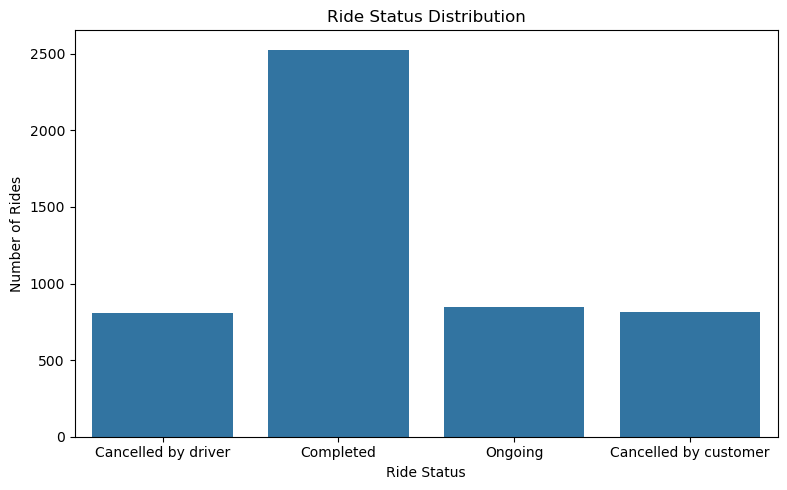

In [40]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x="Ride_status")

plt.title("Ride Status Distribution")
plt.xlabel("Ride Status")
plt.ylabel("Number of Rides")


plt.tight_layout()
plt.show()

### Ride Status

In [41]:
print(df['Ride_status'].value_counts())

Ride_status
Completed                2527
Ongoing                   846
Cancelled by customer     816
Cancelled by driver       811
Name: count, dtype: int64


# 2. Driver Cancellation by Vehicle Type

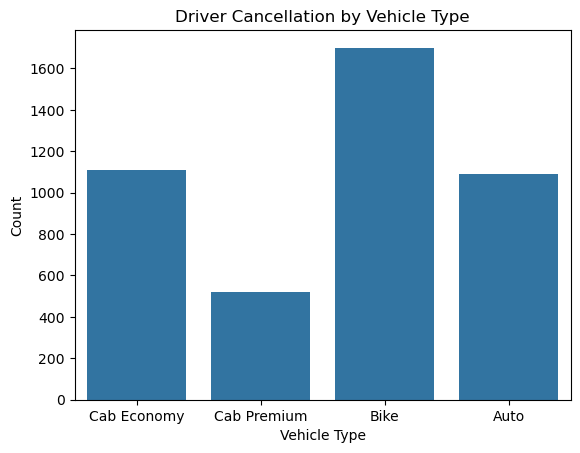

In [42]:
sns.countplot(data=df, x="Vehicle_Type")

plt.title("Driver Cancellation by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Count")
plt.show()

# Driver Cancellation by City

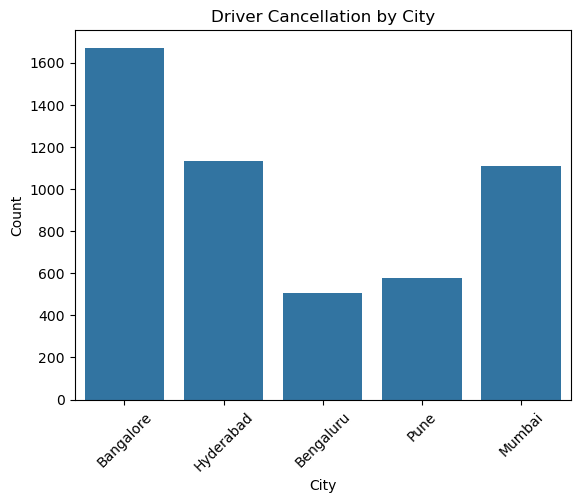

In [43]:
sns.countplot(data=df, x="City")

plt.title("Driver Cancellation by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Vehicle Type + Weather

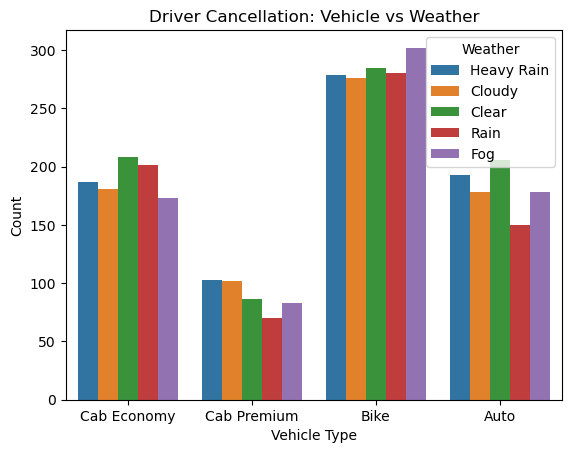

In [44]:
sns.countplot(data=df, x="Vehicle_Type", hue="Weather")
plt.title("Driver Cancellation: Vehicle vs Weather")
plt.xlabel("Vehicle Type")
plt.ylabel("Count")
plt.legend(title="Weather")
plt.show()

In [45]:
# Filter for driver-cancelled rides
driver = df[df["Ride_status"] == "Cancelled by driver"]

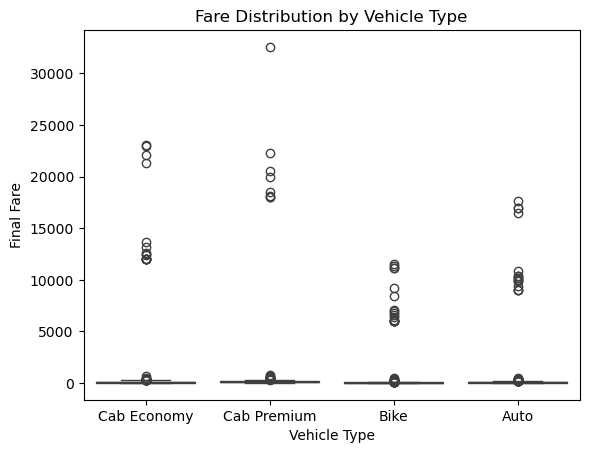

In [46]:
sns.boxplot(data=df, x="Vehicle_Type", y="Final_fare")
plt.title("Fare Distribution by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Final Fare")
plt.show()

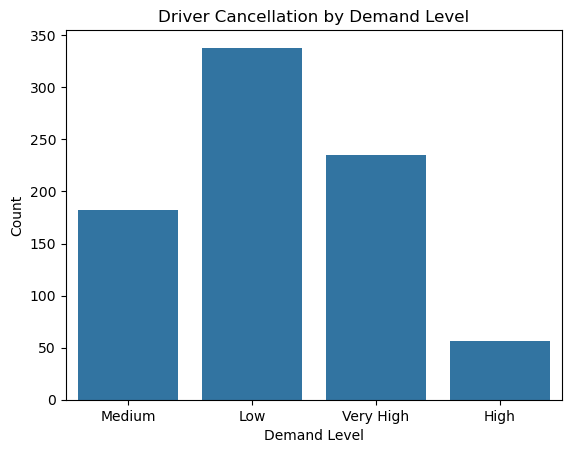

In [47]:
sns.countplot(data=driver, x="Demand_Level")
plt.title("Driver Cancellation by Demand Level")
plt.xlabel("Demand Level")
plt.ylabel("Count")
plt.show()

# problems

1. Bike and Auto drivers earn too little per ride

Bike drivers earn ₹51.5 on average, Auto ₹72.3 — much less than Cab Economy (₹85.1) and Cab Premium (₹120.5).
Low earnings make drivers less willing to accept or complete  rides.
    
Simple fix: Set a minimum fare for Bike/Auto rides and give bonuses after completing a certain number of rides.

2. Surge pricing isn't stopping drivers from cancelling

Cancelled rides and completed rides have almost the same surge multiplier (~1.14–1.16x).
This means higher pricing during busy times isn't actually convincing drivers to stay on the ride.

Simple fix: Make sure drivers clearly see how much extra they earn from surge, and increase their share of it.

3. Most cancellations happen during low demand, not high demand

338 cancellations happen when demand is Low, but only 56 happen when demand is High.
This is the opposite of what you'd expect — normally you'd think drivers cancel more when they're busy and picky.
It likely means during low demand, drivers are getting assigned rides that aren't worth their time.

Simple fix: Offer a small bonus during low-demand hours so drivers still find it worthwhile to accept rides.

# solution
Performance incentives encourage drivers to complete more rides.

set a minimum guaranteed fare for bike/auto rides below a distance threshold, so short trips are still worth accepting.
Introduce per-vehicle incentive slabs — e.g., bonus for completing 10+ bike rides/day — to offset naturally lower per-ride fares.
Show estimated earnings before accept, not just pickup distance, so low-fare rides don't get silently skipped.



Trip earnings display allows drivers to see expected income before accepting.

Cancellation penalties discourage unnecessary cancellations.

# 2. CUSTOMER CANCELLATION

In [48]:
customer_cancel = df[df["Ride_status"] == "Cancelled by customer"]

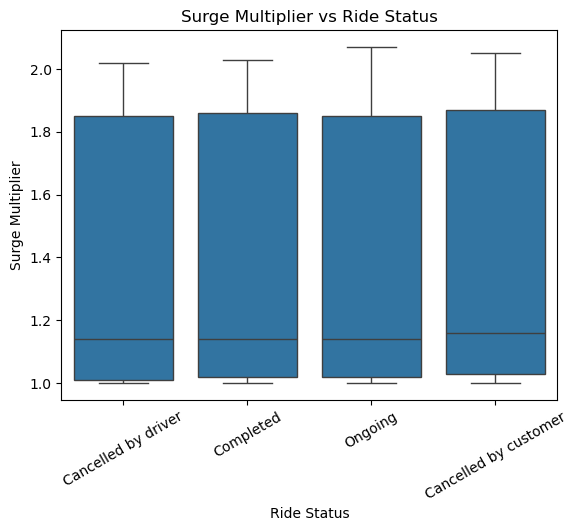

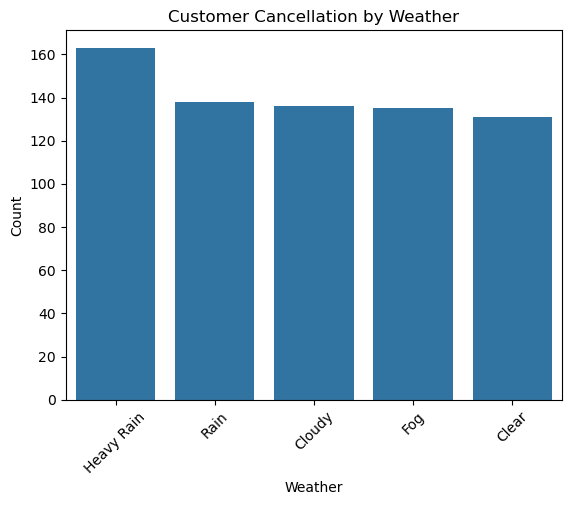

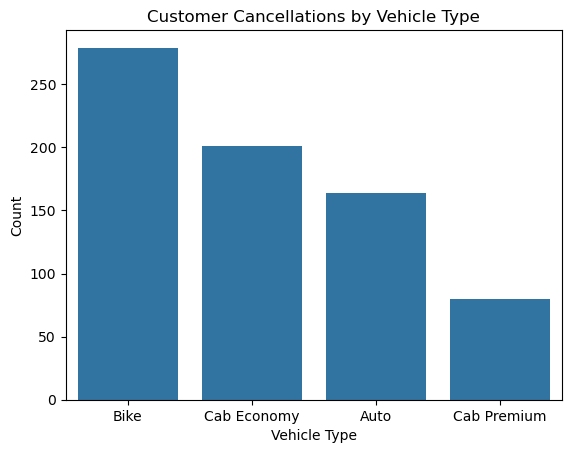

In [49]:
# Step 1: define the filter first
customer_cancel = df[df["Ride_status"] == "Cancelled by customer"]

# Graph 1: Surge Pricing vs Ride Status 
sns.boxplot(data=df, x="Ride_status", y="Surge_multiplier", showfliers=False)
plt.title("Surge Multiplier vs Ride Status")
plt.xlabel("Ride Status")
plt.ylabel("Surge Multiplier")
plt.xticks(rotation=30)
plt.show()

# Graph 2: Customer Cancellations by Weather
sns.countplot(data=customer_cancel, x="Weather",
              order=customer_cancel["Weather"].value_counts().index)
plt.title("Customer Cancellation by Weather")
plt.xlabel("Weather")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Graph 3: Customer Cancellations by Vehicle Type
sns.countplot(data=customer_cancel, x="Vehicle_Type",
              order=customer_cancel["Vehicle_Type"].value_counts().index)
plt.title("Customer Cancellations by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Count")
plt.show()

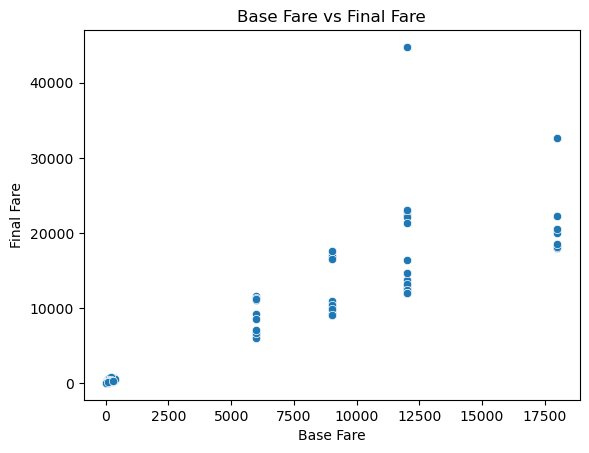

In [50]:
sns.scatterplot(data=df,x="Base_fare",y="Final_fare")

plt.title("Base Fare vs Final Fare")
plt.xlabel("Base Fare")
plt.ylabel("Final Fare")
plt.show()

1. Surge Pricing Discourages Customers

Customers cancel more when surge is higher (1.16x) vs normal rides (1.14x)
High surge prices surprise customers, so they cancel

Fix: Cap surge during peak hours + show why price is high before booking

2. Bad Weather Drives Cancellations

Most customer cancellations happen in Heavy Rain (163) vs Clear weather (131)
Customers lose confidence in getting a ride during bad weather

Fix: Guarantee driver arrival time during rain + give small discount as reassurance

3. Bike Rides Get Cancelled the Most

Bike has 279 cancellations — way more than Cab Premium (80)
Customers trust bikes the least, even though they're cheapest

Fix: Add live tracking, accurate ETA, and safety assurance (like helmet) for bike rides

# solution
Improve ETA (arrival time) accuracy.

Show live driver location.

Allow customers to change the pickup location instead of cancelling.



# 3. surge pricing

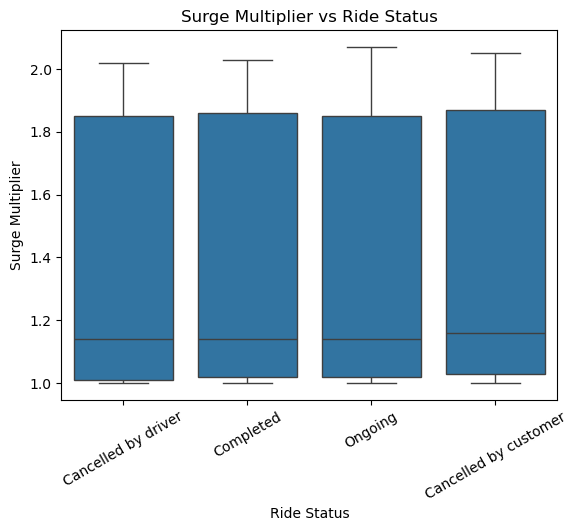

In [51]:
sns.boxplot(data=df, x="Ride_status", y="Surge_multiplier", showfliers=False)
plt.title("Surge Multiplier vs Ride Status")
plt.xlabel("Ride Status")
plt.ylabel("Surge Multiplier")
plt.xticks(rotation=30)
plt.show()

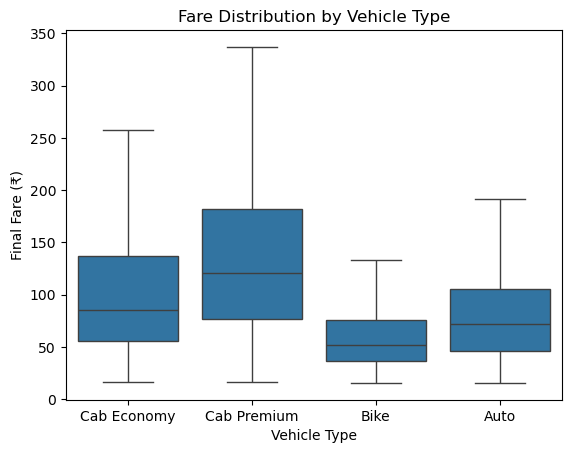

In [52]:
sns.boxplot(data=df, x="Vehicle_Type", y="Final_fare", showfliers=False)
plt.title("Fare Distribution by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Final Fare (₹)")
plt.show()

1. Customer cancellations rise steadily as surge increases

Cancellation rate climbs from 15.6% (low surge) → 16.1% (mild) → 17.5% (moderate) → 18.2% (high surge).
Higher surge = more customers backing out before the ride happens.
    
Solution: Cap surge at a reasonable level (e.g., 2x) and show the reason for the price increase before checkout.

2. Very few rides actually complete at high surge

Only 40 rides complete at high surge (>2x), compared to 1,064 at low surge — a huge drop-off in volume.
Even though the average fare is high (₹1,375), the total business happening at high surge is tiny.
    
Solution: Instead of unlimited surge, use smaller, more gradual price increases so customers keep booking instead of abandoning at high prices.

3. Surge pricing helps drivers, but not customers — creating an imbalance

Driver cancellations actually go down as surge increases (17.1% → 13.0%), meaning drivers like higher surge.
But customer cancellations go up at the same time (15.6% → 18.2%) — the opposite effect.
This means surge pricing benefits one side of the marketplace while hurting the other.
    
Solution: Balance the incentive — instead of only increasing price for customers, share more of the surge amount with drivers without raising customer price as steeply.

# Surge Pricing
Solutions:

Set a maximum limit on surge pricing.

Offer discounts or coupons during peak hours.

Reward loyal customers with special offers



# 4. Missing Customer Ratings

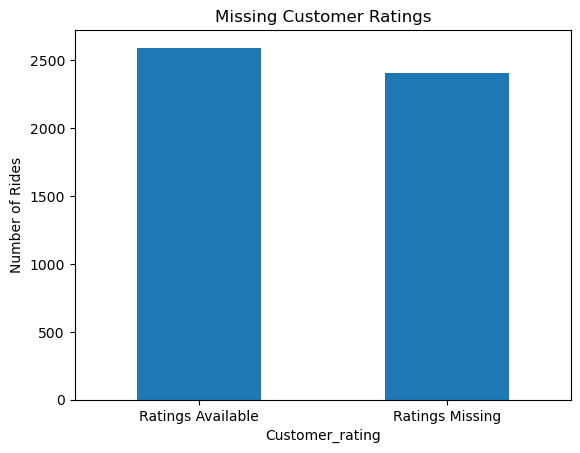

In [53]:
df['Customer_rating'].isnull().value_counts().plot(kind='bar')
plt.title("Missing Customer Ratings")
plt.xticks([0,1], ['Ratings Available','Ratings Missing'], rotation=0)
plt.ylabel("Number of Rides")
plt.show()

51.8% of all rides (2,592 of 5,000) are missing a rating. Breaking it down by status confirms the reason: every single non-completed ride (Ongoing, Cancelled by driver, Cancelled by customer — 2,473 rides) has no rating, since a ride that never finished can't be rated. Even among Completed rides, 119 are still missing a rating — meaning some customers simply skip rating after a successful trip.

Send a quick rating reminder notification right after the ride ends.
    
Give a small reward (discount/coupon) for rating, to boost response rate.

# 5 . Weather-Related Operational Challenges

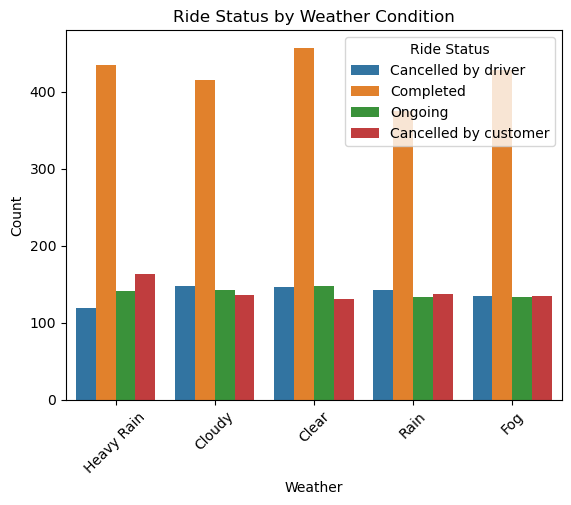

In [54]:
sns.countplot(data=df, x="Weather", hue="Ride_status")
plt.title("Ride Status by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Ride Status")
plt.show()

 Heavy Rain has the highest combined cancellation rate — customer cancellations spike to 19.0% during Heavy Rain vs 14.9% in Clear weather, while driver cancellations dip slightly (13.9% vs 16.6% in Clear). Rain (non-heavy) is also elevated for driver cancellations (18.1%). Completed-ride rate drops to its lowest in Rain (47.5%) and Heavy Rain (50.7%) compared to Clear (51.8%).

Solution:

Customer side (Heavy Rain, 19% cancel): show live driver tracking + accurate ETA during rain so customers trust the ride will arrive, instead of cancelling and switching to another option.

Driver side (Rain, 18.1% cancel): offer a small rain-completion bonus, since bad-weather driving is less desirable but still needed to keep supply up.

Add a weather-based buffer to ETA estimates — inflated/inaccurate ETA during rain is a likely hidden cause of both customer and driver drop-off, and isn't captured directly in this dataset but is worth testing operationally.

Weather-Related Challenges

Show live driver location and accurate ETA during rain so customers don't cancel out of uncertainty.

Give drivers a small bonus for completing rides in bad weather, so they're less likely to cancel.

In [45]:
#Which city has the highest number of rides?
df["City"].value_counts()

City
Bangalore    1701
Hyderabad    1150
Mumbai       1117
Pune          593
Bengaluru     514
Name: count, dtype: int64

In [46]:
#Which vehicle type is most popular?
df["Vehicle_Type"].value_counts()

Vehicle_Type
Bike           1720
Cab Economy    1130
Auto           1105
Cab Premium     529
Name: count, dtype: int64

In [47]:
#What is the average fare?
df["Final_fare"].mean()

np.float64(263.99680287474337)

In [137]:
#What is the average distance?
df["Distance_km"].mean()

np.float64(18.203052000000003)

In [102]:
#Which city generates the highest average fare?
df.groupby("City")["Final_fare"].mean().sort_values(ascending=False)

City
Bangalore    305.043807
Mumbai       283.428447
Bengaluru    248.118261
Hyderabad    229.425476
Pune         210.897046
Name: Final_fare, dtype: float64

In [103]:
#Which vehicle type generates the highest average fare?
df.groupby("Vehicle_Type")["Final_fare"].mean().sort_values(ascending=False)

Vehicle_Type
Cab Premium    471.096119
Cab Economy    313.892521
Auto           259.706740
Bike           142.147571
Name: Final_fare, dtype: float64

In [104]:
#Which payment method is most commonly used?
df["Payment_method"].value_counts()

Payment_method
Upi       1266
Cash      1265
Wallet    1242
Card       611
Name: count, dtype: int64

In [52]:
#What is the cancellation rate?
cancelled = df[
    df["Ride_status"].str.contains("cancelled", case=False, na=False)]

cancellation_rate = len(cancelled) / len(df) * 100

print("Cancellation Rate:", cancellation_rate, "%")

Cancellation Rate: 32.520165256738146 %


Conclusion

From the Rapido ride analysis, we found that about 32.5% of rides were cancelled.

The main reasons are:

Surge Pricing:
Higher surge pricing increases customer cancellations, even though it helps reduce driver cancellations.
    
Low Driver Earnings:
Bike and Auto drivers earn less, which leads to more driver cancellations.
    
Weather and Reliability:
Heavy rain increases cancellations because customers may feel the ride is less reliable.
Overall Conclusion

The main cancellation problems are high surge prices, low driver earnings, and bad weather. Rapido can reduce cancellations by controlling surge pricing, improving driver earnings, and providing better support during bad weather.